Import Libraries:

In [1]:
import PIL.Image as image
import matplotlib.pyplot as plt
import numpy as np

Read Image:

In [3]:
img = image.open('images/dollar.tif').convert('L')
img_arr = np.array(img)

Extract all 8 bit planes:

In [4]:
bit_planes = []

for k in range(8):
    plane = (img_arr >> k) & 1
    bit_planes.append(plane)
    

display all bit planes in 2x4

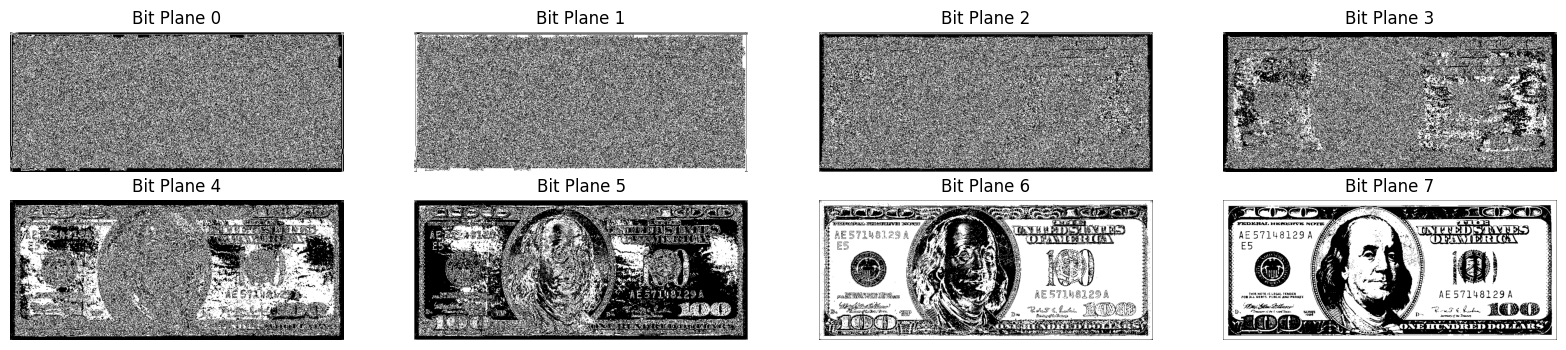

In [5]:
plt.figure(figsize=(20,4))

for k in range(8):
    plt.subplot(2,4,k+1)
    plt.imshow(bit_planes[k], cmap='gray')
    plt.title(f"Bit Plane {k}")
    plt.axis("off")
plt.show()

reconstructing image using higher-order bit planes (4-7):

In [6]:
recon = np.zeros_like(img_arr)

for k in range(4,8):
    recon = recon + bit_planes[k] * (2**k)

Original and reconstructed image

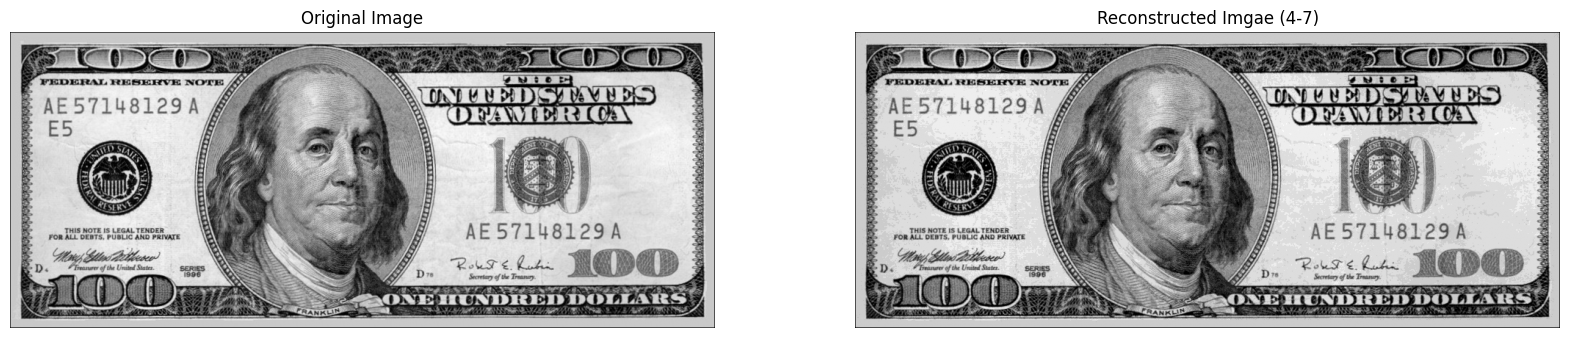

In [7]:
plt.figure(figsize=(20,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(recon, cmap='gray')
plt.title('Reconstructed Imgae (4-7)')
plt.axis('off')
plt.show()